# Applied Trading Strategies

## Trading Game: True Alpha or Fluke (probably fluke)


For each group, assume excess return of 0 and vol of 5% (the drawdown limit is 5% in the first 2 weeks and 7.5% in the last 3 weeks - Overall, I'm assuming the annualised vol is 7% to simplify -- vol and DD are not the same!)
We have 12 groups (including the group of the instructor/TA) trading for 5 weeks. How can we determine if a group ends up with a significant P&L that it's due to skill/alpha and not pure luck?

Suggest something like the below. Or come up with your own approach:  
For each group, assume excess return of 0 and vol of 7.5% (the drawdown limit is 5% in the first 2 weeks and 7.5% in the last 3 weeks - I'm assuming the ann. vol is 7.5% to simplify -- vol and DD are not the same)  
  
Step 1 - Run MC simulations with N ~ (0, 7.5%) - in each sim, run 12 x 5-week performances  
Step 2 - For each sim, pick out the return of the best (the max)  
Step 3 - Run another set of MC simulations with each sim using the distribution of the max from Step 1 - same return and vol.  
This should give a return distribution of the max of the 12 groups assuming zero alpha.  
Step 4 - Compare the max P&L of the 12 groups over the 5 weeks vs. the distribution in Step 3 using a hypothesis test to determine (best guess)if that P&L is due to alpha or luck.  
Step 5 - Additionally, maybe compare the 1/n portfolio of all 12 groups (an implicit fund of funds or an equal-weighted multi-strat fund) vs the distribution in Step 1 - Goal is to quantify x% probability that the whole class has a Sharpe Ratio of > 0.  
  
Attached is the JPM paper "Androids" for short, that we briefly discuss in class. Exhibit 4 (Page 5) may give you more ideas - it gives a distribution of Sharpe Ratios and with a vertical slice/cross section taken to figure out if a high realised SR is due to luck or skill.

### my understanding of what's going on - skip
So the null hypothesis, H_0 -> The group has zero alpha (pure fluke)

MC simulation builds a normal distribution of what the best group looks like assuming everyone is lucky (0 alpha so should be normally dist4ributed around the mean of 0 - makes sense that half would win, half would lose) -> zero skill would equal avg zero alpha.

If highest groups returns hit the 95 percentile of the dist, only 5% of lucky winners ever get this high returns -> too extreme to explain the null (or 99p if doubtful) -> sufficient evidence to reject the null -> pure skill!!

In [2]:
# importing required libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# Step 0 - setting up stuff

ann_vol  = 0.075 # assumed annual volatility of 7.5%
n_groups = 12 # 12 groups
n_weeks = 5 # trading game over 5 weeks
n_sims = 10000 # number of MC simulations to run

# Converting annual volatility to 5-week volatility
'''
5_week_volatility = annual_volatility * sqrt(5 / 52)
'''
vol_5w = ann_vol * np.sqrt(n_weeks / 52)
print(f'5-week volatility: {vol_5w:.4f}')

5-week volatility: 0.0233


95th percentile of lucky winner (need to exceed to be lucky): 6.11%
99th percentile of lucky winner (need to exceed to be very lucky): 7.28%


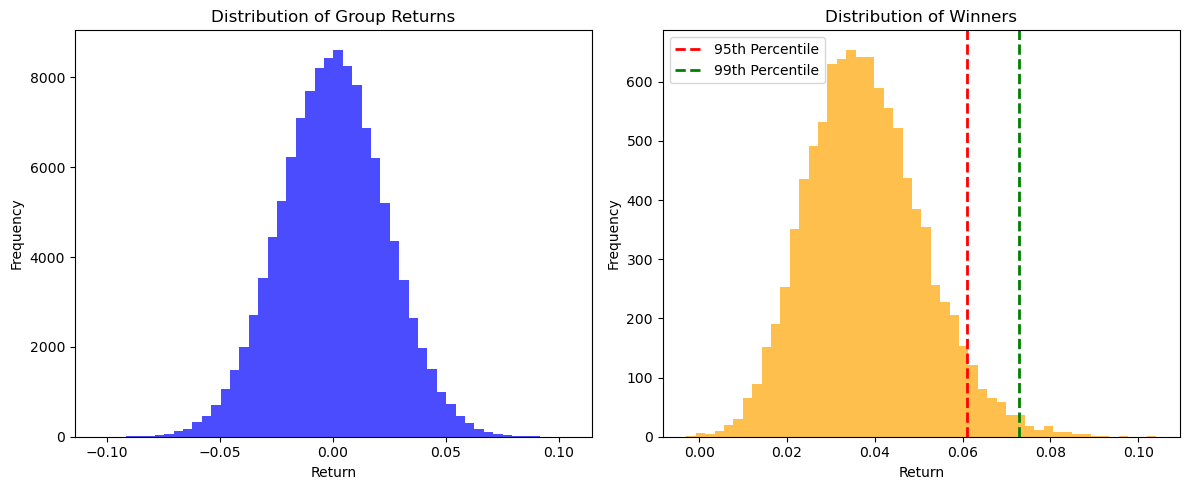

In [4]:
# null distribution of regular returns and winners

np.random.seed(42)
returns = np.random.normal(loc=0, scale=vol_5w, size=(n_sims, n_groups)) #assuming 0 alpha

# from each simulation, find the winner (max return)
winners = returns.max(axis=1)

# thresholds for winners (1 and 5%)
p95 = np.percentile(winners, 95)
p99 = np.percentile(winners, 99)

print(f"95th percentile of lucky winner (need to exceed to be lucky): {p95:.2%}")
print(f"99th percentile of lucky winner (need to exceed to be very lucky): {p99:.2%}")

#plot graphs of normal distribution of returns and winners
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(returns.flatten(), bins=50, alpha=0.7, color='blue')
plt.title('Distribution of Group Returns')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.subplot(1, 2, 2)
plt.hist(winners, bins=50, alpha=0.7, color='orange')
plt.title('Distribution of Winners')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.axvline(x=p95, color='red', linestyle='dashed', linewidth=2, label='95th Percentile')
plt.axvline(x=p99, color='green', linestyle='dashed', linewidth=2, label='99th Percentile')
plt.legend()
plt.show()


In [5]:
# using our actual returns to compare
df = pd.read_csv('group_pnl.csv')
df = df.set_index('group')

#print(df)

#convert to decimal returns
notional = 100_000_000
returns_df = df.div(notional) 
print(returns_df)

cumulative_returns = returns_df['cumulative']
print("Cumulative returns:")
print(cumulative_returns.apply(lambda x: f"{x:.2%}"))

# current winner is group 1 with cum returns 14.653%
actual = cumulative_returns.loc[1]
p_value = np.mean(winners >= actual)
p95 = np.percentile(winners, 95)
p99 = np.percentile(winners, 99)

print(f"\nGroup 1 actual return : {actual:.2%}")
print(f"5-week sigma          : {vol_5w:.2%}")
print(f"95th pct (lucky winner): {p95:.2%}")
print(f"99th pct (lucky winner): {p99:.2%}")
print(f"p-value               : {p_value:.3f}")


          week1     week2     week3     week4  cumulative
group                                                    
1      0.047486  0.078547  0.000220  0.020281    0.146534
2     -0.001110 -0.001881  0.032015  0.002271    0.031295
3     -0.001237  0.001918 -0.012604  0.002790   -0.009133
4      0.000035  0.043680 -0.026087 -0.024225   -0.006598
5      0.001479  0.045032 -0.018316  0.008471    0.036665
6     -0.001059  0.012034 -0.004661 -0.004580    0.001733
7      0.000951  0.018025  0.008683 -0.042716   -0.015058
8      0.000210  0.004480  0.019894  0.002666    0.027251
9      0.007040  0.008699 -0.003933 -0.011527    0.000279
10     0.004527 -0.003556 -0.001825  0.004166    0.003311
11     0.008086  0.009931 -0.026253  0.005413   -0.002824
12    -0.002050  0.014549 -0.003561  0.012511    0.021449
Cumulative returns:
group
1     14.65%
2      3.13%
3     -0.91%
4     -0.66%
5      3.67%
6      0.17%
7     -1.51%
8      2.73%
9      0.03%
10     0.33%
11    -0.28%
12     2.14%
Name: 

So, for group 1, with 10,000 distributions, statsitically their returns are way beyond the 99th percentile of 7.28% -> no simulated lucky winner beats it in 10,000 runs of the model. 

But, only 5 weeks of data and most of the return driven by week 2 (put options if i remember correctly?). Statistically pure alpha, but as it is not my group, I am doubtful !


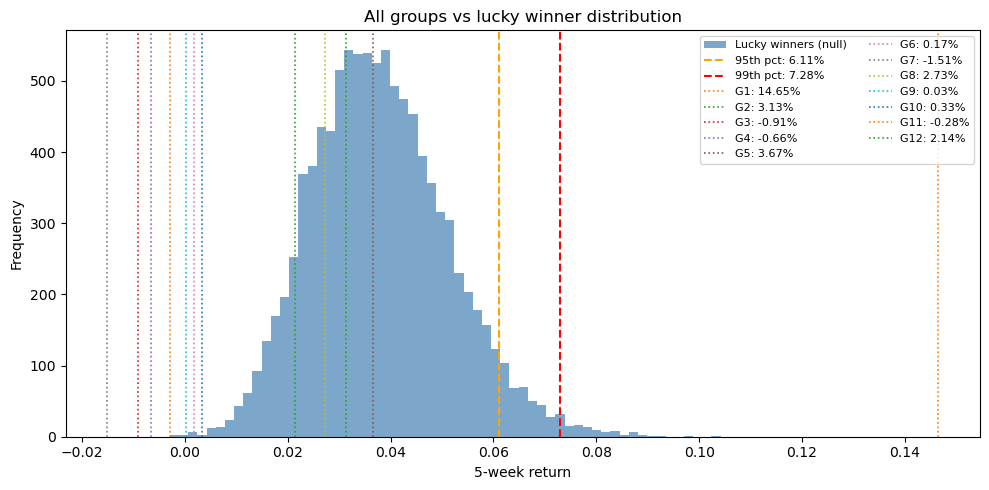

In [6]:
# a fun plot to visualize where we are end of week 4 trading game

plt.figure(figsize=(10, 5))
plt.hist(winners, bins=60, alpha=0.7, color='steelblue', label='Lucky winners (null)')
plt.axvline(p95, color='orange', linestyle='--', linewidth=1.5, label=f'95th pct: {p95:.2%}')
plt.axvline(p99, color='red',    linestyle='--', linewidth=1.5, label=f'99th pct: {p99:.2%}')

# plot every group's actual return
colors = plt.cm.tab10.colors
for group in cumulative_returns.index:
    r = cumulative_returns.loc[group]
    plt.axvline(r, color=colors[group % 10], linewidth=1.2, 
                linestyle=':', label=f'G{group}: {r:.2%}')

plt.xlabel('5-week return')
plt.ylabel('Frequency')
plt.title('All groups vs lucky winner distribution')
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## Step 5 - Claude code to compare the 1/n portfolio of all 12 groups 

(an implicit fund of funds or an equal-weighted multi-strat fund) vs the distribution in Step 1 - Goal is to quantify x% probability that the whole class has a Sharpe Ratio of > 0

In [7]:
# ── STEP 5: equal-weighted portfolio ─────────────────────────

# 1/N portfolio return = simple average of all 12 groups
eq_portfolio_actual = cumulative_returns.mean()
print(f"Equal-weighted portfolio actual return: {eq_portfolio_actual:.2%}")

# the MC equivalent — average the 12 random groups in each simulation
# returns shape is (n_sims, n_groups), so mean across columns
eq_portfolio_sim = returns.mean(axis=1)  # shape (10000,)

# where does our actual portfolio sit in the null distribution?
p_value_eq = np.mean(eq_portfolio_sim >= eq_portfolio_actual)
p95_eq = np.percentile(eq_portfolio_sim, 95)
p99_eq = np.percentile(eq_portfolio_sim, 99)

print(f"95th pct (equal-weighted null): {p95_eq:.2%}")
print(f"99th pct (equal-weighted null): {p99_eq:.2%}")
print(f"p-value (whole class has alpha): {p_value_eq:.3f}")

Equal-weighted portfolio actual return: 1.96%
95th pct (equal-weighted null): 1.11%
99th pct (equal-weighted null): 1.61%
p-value (whole class has alpha): 0.002


In [8]:
# ── Sharpe Ratio of the equal-weighted portfolio ──────────────
# Sharpe = mean return / vol of returns (annualised)

# actual weekly returns for the equal-weighted portfolio
weekly_cols = ['week1', 'week2', 'week3', 'week4']
eq_weekly = returns_df[weekly_cols].mean(axis=0)  # average across groups each week

sharpe_actual = eq_weekly.mean() / eq_weekly.std() * np.sqrt(52)  # annualised
print(f"\nEqual-weighted portfolio Sharpe: {sharpe_actual:.2f}")

# MC Sharpe distribution — simulate 4 weekly returns per sim, compute Sharpe each time
weekly_sims = np.random.normal(0, vol_5w/np.sqrt(5), size=(n_sims, 4))
# (dividing by sqrt(5) to get weekly vol from 5-week vol)
eq_weekly_sims = weekly_sims.mean(axis=1)  # equal-weight across groups already done via normal(0,...)

# Sharpe for each simulated path
sharpe_sims = (weekly_sims.mean(axis=1) / weekly_sims.std(axis=1)) * np.sqrt(52)

pct_positive_sharpe = np.mean(sharpe_sims > 0) * 100
print(f"% of simulations with Sharpe > 0: {pct_positive_sharpe:.1f}%")
print(f"(under null this should be ~50%)")

p_value_sharpe = np.mean(sharpe_sims >= sharpe_actual)
print(f"p-value (Sharpe): {p_value_sharpe:.3f}")


Equal-weighted portfolio Sharpe: 3.43
% of simulations with Sharpe > 0: 50.1%
(under null this should be ~50%)
p-value (Sharpe): 0.235


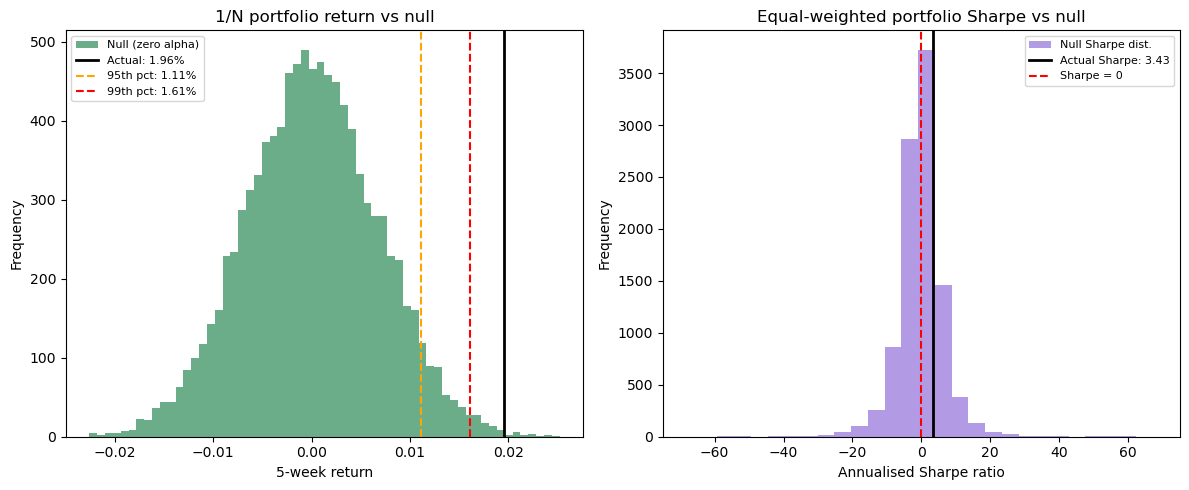

In [13]:
# ── plot both distributions side by side ─────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# left: equal-weighted return distribution
ax1.hist(eq_portfolio_sim, bins=60, alpha=0.7, color='seagreen', label='Null (zero alpha)')
ax1.axvline(eq_portfolio_actual, color='black', linewidth=2, 
            label=f'Actual: {eq_portfolio_actual:.2%}')
ax1.axvline(p95_eq, color='orange', linestyle='--', linewidth=1.5,
            label=f'95th pct: {p95_eq:.2%}')
ax1.axvline(p99_eq, color='red', linestyle='--', linewidth=1.5,
            label=f'99th pct: {p99_eq:.2%}')
ax1.set_title('1/N portfolio return vs null')
ax1.set_xlabel('5-week return')
ax1.set_ylabel('Frequency')
ax1.legend(fontsize=8)

# right: Sharpe ratio distribution
ax2.hist(sharpe_sims, bins=60, alpha=0.7, color='mediumpurple', label='Null Sharpe dist.')
ax2.axvline(sharpe_actual, color='black', linewidth=2,
            label=f'Actual Sharpe: {sharpe_actual:.2f}')
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Sharpe = 0')
ax2.set_title('Equal-weighted portfolio Sharpe vs null')
ax2.set_xlabel('Annualised Sharpe ratio')
ax2.set_xlim(-75, 75) # just to see sharpe distribution better
ax2.set_ylabel('Frequency')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

By averaging the groupss, vol shrinks by sqrt(12) as seen in the graphs above -> null distribution shrinks. 

Graph on the right implies that between all 12 groups, we have pure skill (no fluke!!) Under the null, the sharpe of the class should be exactly 0 (or j symmetric around 0), so class as a whole has an edge. 

But, as class avg is positive and significant, potentially the rules of the game that are generating alpha rather than the entire class being professional traders (vega limits, drawdown limits, covered options until now etc).